In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

INPUT_PATH = "../../../data/phase2/labeled_signals.parquet"

# Phase 2 logistic regression baseline (from notebook 04, corrected 76-fold run)
LR_TRADES    = 2580
LR_WIN_RATE  = 0.757
LR_BRIER     = 0.1148
LR_EV        = 0.3626

NADEX_WIN_PAYOUT = 0.80
NADEX_LOSS_COST  = 1.00

EXISTING_FEATURES = [
    "ema_ratio", "rsi_14", "macd_hist", "atr_14",
    "session_quality_enc", "direction_enc", "signal_valid_enc",
]
NEW_FEATURES = ["ema_20", "ema_50", "macd", "macd_signal", "instrument_enc"]
FEATURE_COLS = EXISTING_FEATURES + NEW_FEATURES
LABEL_COL = "label"
META_COLS = ["date", "s3_key", "fold", "split"]

In [3]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived and encoded columns. Returns new DataFrame."""
    out = df.copy()
    out["ema_ratio"]           = out["ema_20"] / out["ema_50"]
    out["session_quality_enc"] = out["session_quality"].map({"high": 2, "medium": 1, "low": 0})
    out["direction_enc"]       = out["direction"].map({"buy": 1, "sell": -1, "none": 0})
    out["signal_valid_enc"]    = out["signal_valid"].astype(int)
    le = LabelEncoder()
    out["instrument_enc"]      = le.fit_transform(out["s3_key"])
    return out


def assign_walk_forward_folds(
    df: pd.DataFrame,
    train_months: int = 6,
    test_months: int = 1,
) -> pd.DataFrame:
    """
    Assign walk-forward fold metadata. Returns an exploded DataFrame where each
    row appears once per fold it participates in (as train or test).
    A row may appear as train in multiple folds. Each fold is fully independent.
    Rows that don't fall into any fold window are excluded.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["_orig"] = range(len(df))

    min_date = df["date"].min().to_period("M")
    max_date = df["date"].max().to_period("M")
    month_period = df["date"].dt.to_period("M")

    fold_idx, cursor, fold_windows = 0, min_date, []
    while True:
        train_end = cursor + train_months
        test_end  = train_end + test_months
        if test_end > max_date + 1:
            break
        fold_windows.append((fold_idx, cursor, train_end, train_end, test_end))
        fold_idx += 1
        cursor += test_months

    records = []
    for fi, train_start, train_end, test_start, test_end in fold_windows:
        train_idx = df.index[(month_period >= train_start) & (month_period < train_end)]
        test_idx  = df.index[(month_period >= test_start)  & (month_period < test_end)]
        for i in train_idx:
            records.append({"_orig": i, "fold": fi, "split": "train"})
        for i in test_idx:
            records.append({"_orig": i, "fold": fi, "split": "test"})

    fold_df = pd.DataFrame(records)
    result = df.merge(fold_df, on="_orig", how="inner")
    return result.drop(columns=["_orig"]).reset_index(drop=True)


def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    """Drop NaN labels, encode features, assign folds. Returns model-ready DataFrame."""
    df = df[df["label"].notna()].copy()
    df = encode_features(df)
    df = assign_walk_forward_folds(df)
    keep = META_COLS + FEATURE_COLS + [LABEL_COL]
    return df[keep].reset_index(drop=True)

In [4]:
raw = pd.read_parquet(INPUT_PATH)
prepped = prepare_features(raw)

print(f"Total rows after dropping direction=none: {len(prepped)}")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nAny NaN in features: {prepped[FEATURE_COLS].isna().any().any()}")
print(f"\nLabel distribution:\n{prepped[LABEL_COL].value_counts()}")
print(f"\nFolds with train+test: {prepped[prepped['split']=='train']['fold'].nunique()}")

Total rows after dropping direction=none: 37235
Feature columns (12): ['ema_ratio', 'rsi_14', 'macd_hist', 'atr_14', 'session_quality_enc', 'direction_enc', 'signal_valid_enc', 'ema_20', 'ema_50', 'macd', 'macd_signal', 'instrument_enc']

Any NaN in features: False

Label distribution:
label
0.0    20820
1.0    16415
Name: count, dtype: int64

Folds with train+test: 76


/var/folders/67/xsn6f8gs2t94xg1kmbx02mjw0000gn/T/ipykernel_92379/955832983.py:28: UserWarning: Converting to Period representation will drop timezone information.
  min_date = df["date"].min().to_period("M")
/var/folders/67/xsn6f8gs2t94xg1kmbx02mjw0000gn/T/ipykernel_92379/955832983.py:29: UserWarning: Converting to Period representation will drop timezone information.
  max_date = df["date"].max().to_period("M")
/var/folders/67/xsn6f8gs2t94xg1kmbx02mjw0000gn/T/ipykernel_92379/955832983.py:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month_period = df["date"].dt.to_period("M")


In [5]:
def win_rate(labels: pd.Series) -> float:
    return float(labels.mean())


def brier_score(labels: pd.Series, probs: pd.Series) -> float:
    return float(((probs - labels) ** 2).mean())


def expected_value(wr: float) -> float:
    return wr * NADEX_WIN_PAYOUT - (1 - wr) * NADEX_LOSS_COST


def summarise(labels: pd.Series, probs: pd.Series) -> dict:
    """Compute win rate, brier, EV for top-50% by prob_itm."""
    threshold = probs.quantile(0.50)
    selected = labels[probs >= threshold]
    selected_probs = probs[probs >= threshold]
    wr = win_rate(selected)
    return {
        "n_trades":  len(selected),
        "win_rate":  wr,
        "brier":     brier_score(selected, selected_probs),
        "ev":        expected_value(wr),
    }

In [6]:
def run_rf_walk_forward(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run walk-forward validation with two RF models per fold.

    Returns:
        results_df: DataFrame with columns date, s3_key, fold, label,
                    prob_default, prob_tuned
        importance_df: DataFrame with columns fold, feature, importance
                       (from tuned model only)
    """
    folds = sorted(df[df["split"] == "test"]["fold"].unique())
    results = []
    importances = []

    param_grid = {
        "n_estimators": [100, 300],
        "max_depth":    [None, 10, 20],
        "min_samples_leaf": [1, 5, 10],
    }

    for fold_idx in folds:
        train = df[(df["fold"] == fold_idx) & (df["split"] == "train")]
        test  = df[(df["fold"] == fold_idx) & (df["split"] == "test")]

        if len(train) < 10:
            print(f"Fold {fold_idx}: skipping — only {len(train)} train rows")
            continue
        if len(test) == 0:
            print(f"Fold {fold_idx}: skipping — no test rows")
            continue

        X_train = train[FEATURE_COLS].values
        y_train = train[LABEL_COL].values
        X_test  = test[FEATURE_COLS].values

        # Pass 1: default RF
        rf_default = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_default.fit(X_train, y_train)
        prob_default = rf_default.predict_proba(X_test)[:, 1]

        # Pass 2: tuned RF via grid search on train split only
        rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
        gs = GridSearchCV(rf_base, param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
        gs.fit(X_train, y_train)
        prob_tuned = gs.best_estimator_.predict_proba(X_test)[:, 1]

        # Record feature importances from tuned model
        for feat, imp in zip(FEATURE_COLS, gs.best_estimator_.feature_importances_):
            importances.append({"fold": fold_idx, "feature": feat, "importance": imp})

        fold_results = test[["date", "s3_key", "fold", LABEL_COL]].copy()
        fold_results["prob_default"] = prob_default
        fold_results["prob_tuned"]   = prob_tuned

        print(f"Fold {fold_idx}: train={len(train)}, test={len(test)}, best_params={gs.best_params_}")
        results.append(fold_results)

    if not results:
        raise RuntimeError("No folds produced results.")

    return pd.concat(results, ignore_index=True), pd.DataFrame(importances)

In [7]:
print("Running walk-forward RF benchmark (this may take several minutes)...")
results_df, importance_df = run_rf_walk_forward(prepped)

print(f"\nTotal test predictions: {len(results_df)}")
print(f"prob_tuned range: {results_df['prob_tuned'].min():.3f} – {results_df['prob_tuned'].max():.3f}")
print(f"Label distribution in test set:\n{results_df[LABEL_COL].value_counts()}")

Running walk-forward RF benchmark (this may take several minutes)...


Fold 0: train=444, test=71, best_params={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}


Fold 1: train=462, test=67, best_params={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}


Fold 2: train=457, test=84, best_params={'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}


Fold 3: train=487, test=52, best_params={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}


...

Fold 71: train=370, test=49, best_params={'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 300}


Fold 72: train=365, test=26, best_params={'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}


Fold 73: train=337, test=21, best_params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


Fold 74: train=291, test=34, best_params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


Fold 75: train=266, test=12, best_params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}

Total test predictions: 5160
prob_tuned range: 0.000 – 1.000
Label distribution in test set:
label
0.0    2872
1.0    2288
Name: count, dtype: int64


In [8]:
default_metrics = summarise(results_df[LABEL_COL], results_df["prob_default"])
tuned_metrics   = summarise(results_df[LABEL_COL], results_df["prob_tuned"])

comparison = pd.DataFrame([
    {
        "Model":    "Logistic Regression (Phase 2)",
        "Trades":   LR_TRADES,
        "Win Rate": LR_WIN_RATE,
        "Brier":    LR_BRIER,
        "EV/$1":    LR_EV,
    },
    {
        "Model":    "RF Default (n=100)",
        "Trades":   default_metrics["n_trades"],
        "Win Rate": round(default_metrics["win_rate"], 3),
        "Brier":    round(default_metrics["brier"], 4),
        "EV/$1":    round(default_metrics["ev"], 4),
    },
    {
        "Model":    "RF Tuned (GridSearchCV)",
        "Trades":   tuned_metrics["n_trades"],
        "Win Rate": round(tuned_metrics["win_rate"], 3),
        "Brier":    round(tuned_metrics["brier"], 4),
        "EV/$1":    round(tuned_metrics["ev"], 4),
    },
])

print("=" * 65)
print("HEAD-TO-HEAD COMPARISON")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)

# Promotion decision
promoted = (
    tuned_metrics["win_rate"] > LR_WIN_RATE and
    tuned_metrics["ev"]       > LR_EV
)
if promoted:
    print("\n✅ RF Tuned BEATS logistic regression on both win rate and EV.")
    print("   Candidate for Phase 4 promotion.")
else:
    print("\n❌ RF Tuned does NOT beat logistic regression on both criteria.")
    print("   Logistic regression remains the Phase 4 candidate.")
    if tuned_metrics["win_rate"] > LR_WIN_RATE:
        print("   (Win rate improved but EV did not.)")
    elif tuned_metrics["ev"] > LR_EV:
        print("   (EV improved but win rate did not.)")

HEAD-TO-HEAD COMPARISON
                        Model  Trades  Win Rate  Brier  EV/$1
Logistic Regression (Phase 2)    2580     0.757 0.1148 0.3626
           RF Default (n=100)    2622     0.748 0.1400 0.3462
      RF Tuned (GridSearchCV)    2580     0.758 0.1199 0.3640

✅ RF Tuned BEATS logistic regression on both win rate and EV.
   Candidate for Phase 4 promotion.


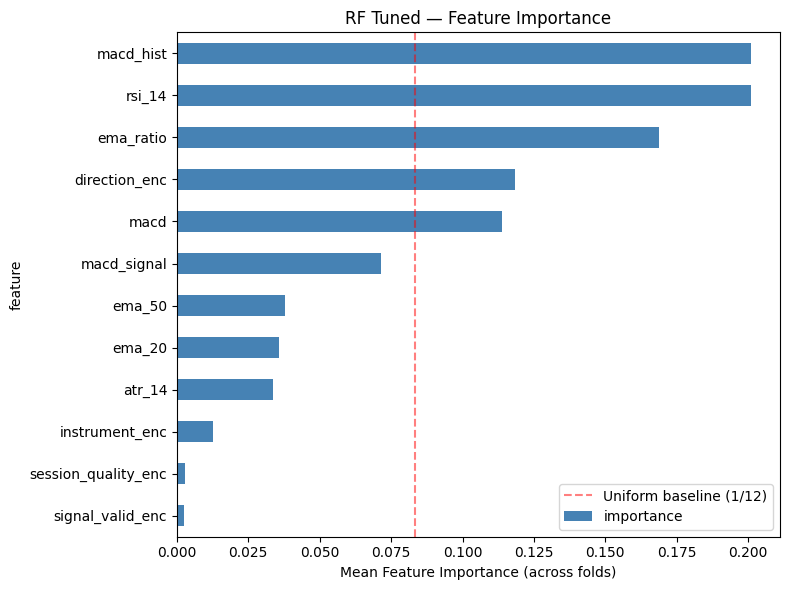


Feature importances (sorted):
feature
macd_hist              0.2011
rsi_14                 0.2010
ema_ratio              0.1688
direction_enc          0.1185
macd                   0.1136
macd_signal            0.0713
ema_50                 0.0379
ema_20                 0.0358
atr_14                 0.0337
instrument_enc         0.0128
session_quality_enc    0.0030
signal_valid_enc       0.0025


In [9]:
mean_importance = (
    importance_df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
mean_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean Feature Importance (across folds)")
ax.set_title("RF Tuned — Feature Importance")
ax.axvline(1 / len(FEATURE_COLS), color="red", linestyle="--", alpha=0.5,
           label=f"Uniform baseline (1/{len(FEATURE_COLS)})")
ax.legend()
plt.tight_layout()
plt.show()

print("\nFeature importances (sorted):")
print(mean_importance.sort_values(ascending=False).round(4).to_string())